# LTN Training Notebook

This notebook trains and compares three model types:
1. **LTN Model** - Neural network with logical rules
2. **MLP Model** - Neural network without rules (baseline)
3. **Rules-Only Model** - Pre-existing model using only logical rules

**Instructions:**
1. Run cells sequentially
2. Modify hyperparameters as needed
3. Both LTN and MLP models will be trained and compared
4. Results are saved for use in Streamlit

## Imports and Setup

In [1]:
import sys
import os

# Add app directory to path for imports
if '/app' not in sys.path:
    sys.path.insert(0, '/app')

import ltn
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import random
import time
import json
import warnings
warnings.filterwarnings("ignore")

# Import utility functions (same as train_ltn.py)
from utils import normalize_value, random_oversample
from paths import OUTPUT_DIR, LTN_RULES_PATH

# Paths
TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
TEST_DIR = os.path.join(OUTPUT_DIR, "test")

print("Imports loaded")

2026-03-08 19:44:12.938300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-08 19:44:12.958562: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-08 19:44:12.966493: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-08 19:44:12.981187: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 19:44:14.413148: W tensorflow/compiler/tf2

Imports loaded


## Configuration

In [2]:
# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 1000
LEARNING_RATE = 0.001
RANDOM_SEED = 99  # Must match the seed used when splitting the dataset

# Model paths
LTN_MODEL_PATH = os.path.join(OUTPUT_DIR, "ltn.h5")
MLP_MODEL_PATH = os.path.join(OUTPUT_DIR, "mlp.h5")
RULES_ONLY_MODEL_PATH = os.path.join(OUTPUT_DIR, "rules_only.h5")

# Set random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# Storage for results
results = {}

print(f"Configuration: {EPOCHS} epochs, batch size {BATCH_SIZE}, LR {LEARNING_RATE}, seed {RANDOM_SEED}")
print(f"Model paths:")
print(f"  LTN: {LTN_MODEL_PATH}")
print(f"  MLP: {MLP_MODEL_PATH}")
print(f"  Rules-only: {RULES_ONLY_MODEL_PATH}")

Configuration: 1000 epochs, batch size 32, LR 0.001, seed 99
Model paths:
  LTN: /app/output/ltn.h5
  MLP: /app/output/mlp.h5
  Rules-only: /app/output/rules_only.h5


## Load Data

In [3]:
# Load training and test data (same as train_ltn.py lines 59-62)
X_train = np.load(f'{TRAIN_DIR}/X_{RANDOM_SEED}.npy')
y_train = np.load(f'{TRAIN_DIR}/y_{RANDOM_SEED}.npy')
X_test = np.load(f'{TEST_DIR}/X_{RANDOM_SEED}.npy')
y_test = np.load(f'{TEST_DIR}/y_{RANDOM_SEED}.npy')

print(f"Data loaded for seed {RANDOM_SEED}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train labels: {np.sum(y_train)} positive, {len(y_train) - np.sum(y_train)} negative")

Data loaded for seed 99
Train: (559, 9), Test: (140, 9)
Train labels: 191 positive, 368 negative


## LTN Operators

In [4]:
# Define LTN operators
Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Or = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())
Forall = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=2), semantics="forall")
Exists = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2), semantics="exists")

formula_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMeanError(p=2))

print("LTN operators defined")

LTN operators defined


## Load Predicates

In [5]:
# Load predicates from saved file (generated from Streamlit)
# This matches the exact approach in train_ltn.py lines 84-86
with open(f"{OUTPUT_DIR}/predicates.txt", 'r') as file:
    preds_code = file.read()

# Execute predicates code to define them in this namespace
# Note: This requires X_train, normalize_value, ltn, tf, Not to be available
exec(preds_code, globals())

print("Predicates loaded from predicates.txt")
print("Available predicates:")
print(preds_code[:500] + "..." if len(preds_code) > 500 else preds_code)

Predicates loaded from predicates.txt
Available predicates:
import tensorflow as tf
import ltn

normalized_clump_thickness_high = normalize_value(X_train, 0, 5.0)
normalized_mitoses = normalize_value(X_train, 8, 5.0)

clump_thickness_high = ltn.Predicate(lambda x: tf.math.greater(x[:, 0], normalized_clump_thickness_high))
mitoses = ltn.Predicate(lambda x: tf.math.less(x[:, 8], normalized_mitoses))

global malignant
global no_malignant
global target
global no_target

malignant = lambda x, y: f(x)
no_malignant = lambda x, y: Not(f(x))
target = malignant
no...


## Model Factory

Define a function to create fresh models. This allows us to train LTN and MLP independently with separate weights.

In [6]:
def create_model(input_size, hidden_layers=(8, 8)):
    """Create a fresh LTN predicate model."""
    return ltn.Predicate.MLP(
        [(input_size,)],
        hidden_layer_sizes=hidden_layers
    )

# Global model variable (will be set before each training run)
f = None

print(f"Model factory ready (input size: {X_train.shape[1]})")

Model factory ready (input size: 9)


## Load Rules and Define Axioms

In [7]:
# Load rules and define axioms (same as train_ltn.py lines 92-108)
rules_file_path = LTN_RULES_PATH  # Uses path from paths.py

def get_axioms(X_train, y_train, use_rules):
    """Get axioms for training - matches train_ltn.py exactly."""
    x = ltn.Variable("x", X_train)
    y = ltn.Variable("y", y_train)
    x_A = ltn.Variable("x_A", tf.boolean_mask(X_train, y_train))
    x_not_A = ltn.Variable("x_not_A", tf.boolean_mask(X_train, tf.logical_not(tf.cast(y_train, tf.bool))))
    
    base_axioms = [
        Forall(x_A, target(x_A, f(x_A))),
        Forall(x_not_A, no_target(x_not_A, f(x_not_A)))
    ]

    axioms = base_axioms
    if use_rules:
        with open(rules_file_path, 'r') as file:
            rules_from_file = file.read()
        exec(rules_from_file, globals())
        axioms = base_axioms + parsed_rules(x, y)
    return axioms

# Test axiom generation (create temp model first)
f = create_model(X_train.shape[1])
test_axioms = get_axioms(X_train[:10], y_train[:10], True)
print(f"Rules file: {rules_file_path}")
print(f"Total axioms with rules: {len(test_axioms)}")

Rules file: /app/output/ltn_rules.txt
Total axioms with rules: 3


## Training Function

In [8]:
def train(X_train_full, y_train_full, epochs, use_rules, save_path, model_name="model"):
    """
    Train the LTN model.
    
    Args:
        X_train_full: Training features
        y_train_full: Training labels
        epochs: Number of training epochs
        use_rules: Whether to include logical rules in training
        save_path: Path to save the best model
        model_name: Name for logging
    
    Returns:
        dict with training history and metrics
    """
    global f
    
    # Create fresh model
    f = create_model(X_train_full.shape[1])
    print(f"\n{'='*60}")
    print(f"Training {model_name} (use_rules={use_rules})")
    print(f"{'='*60}")
    
    # Split into train/val (80/20)
    indices = np.arange(len(X_train_full))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)

    X_tr, y_tr = X_train_full[train_idx], y_train_full[train_idx]
    X_tr, y_tr = random_oversample(X_tr, y_tr, random_state=RANDOM_SEED)
    X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

    print(f"Training on {len(X_tr)} samples, validating on {len(X_val)} samples")

    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    losses = []
    val_losses = []
    val_loss_min = 1e6
    best_epoch = 0

    start_time = time.time()
    
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            axioms = get_axioms(X_tr, y_tr, use_rules)
            sat_level = formula_aggregator(axioms).tensor
            loss = 1. - sat_level
        gradients = tape.gradient(loss, f.trainable_variables)
        optimizer.apply_gradients(zip(gradients, f.trainable_variables))
        losses.append(float(loss.numpy()))

        val_axioms = get_axioms(X_val, y_val, use_rules)
        val_sat = formula_aggregator(val_axioms).tensor
        val_loss = 1. - val_sat
        val_losses.append(float(val_loss.numpy()))

        if val_loss < val_loss_min:
            f.model.save(save_path)
            val_loss_min = val_loss
            best_epoch = epoch

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: Train Sat={sat_level.numpy():.4f}, Val Sat={val_sat.numpy():.4f}, Best={best_epoch}')

    total_time = time.time() - start_time
    print(f"Training complete in {total_time:.1f}s. Best model at epoch {best_epoch}")

    return {
        'losses': losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'training_time': total_time,
        'save_path': save_path
    }

print("Training function defined")

Training function defined


## Train LTN Model (with rules)

In [9]:
# Train LTN model with rules
ltn_history = train(
    X_train, y_train,
    epochs=EPOCHS,
    use_rules=True,
    save_path=LTN_MODEL_PATH,
    model_name="LTN"
)
results['ltn'] = {'history': ltn_history}


Training LTN (use_rules=True)
Training on 582 samples, validating on 112 samples


Epoch 0: Train Sat=0.6573, Val Sat=0.6588, Best=0


Epoch 100: Train Sat=0.8561, Val Sat=0.8795, Best=100


Epoch 200: Train Sat=0.8805, Val Sat=0.9045, Best=200


Epoch 300: Train Sat=0.8920, Val Sat=0.9052, Best=254
Epoch 400: Train Sat=0.8983, Val Sat=0.9024, Best=254
Epoch 500: Train Sat=0.9011, Val Sat=0.8997, Best=254
Epoch 600: Train Sat=0.9026, Val Sat=0.8966, Best=254
Epoch 700: Train Sat=0.9036, Val Sat=0.8932, Best=254
Epoch 800: Train Sat=0.9042, Val Sat=0.8897, Best=254
Epoch 900: Train Sat=0.9048, Val Sat=0.8862, Best=254
Training complete in 110.5s. Best model at epoch 254


## Train MLP Model (no rules)

In [10]:
# Train MLP model without rules
mlp_history = train(
    X_train, y_train,
    epochs=EPOCHS,
    use_rules=False,
    save_path=MLP_MODEL_PATH,
    model_name="MLP"
)
results['mlp'] = {'history': mlp_history}


Training MLP (use_rules=False)
Training on 582 samples, validating on 112 samples
Epoch 0: Train Sat=0.3059, Val Sat=0.3198, Best=0


Epoch 100: Train Sat=0.7423, Val Sat=0.7515, Best=100


Epoch 200: Train Sat=0.8439, Val Sat=0.8617, Best=200


Epoch 300: Train Sat=0.8607, Val Sat=0.8692, Best=300


Epoch 400: Train Sat=0.8708, Val Sat=0.8681, Best=306
Epoch 500: Train Sat=0.8767, Val Sat=0.8675, Best=306
Epoch 600: Train Sat=0.8800, Val Sat=0.8671, Best=306
Epoch 700: Train Sat=0.8820, Val Sat=0.8654, Best=306
Epoch 800: Train Sat=0.8834, Val Sat=0.8624, Best=306
Epoch 900: Train Sat=0.8843, Val Sat=0.8588, Best=306
Training complete in 80.4s. Best model at epoch 306


## Evaluate All Models

In [11]:
def evaluate_model(model_path, X_test, y_test, model_name):
    """Evaluate a saved model and return metrics."""
    try:
        model = tf.keras.models.load_model(model_path)
        y_pred = model(X_test).numpy()
        preds = (y_pred > 0.5).astype(int).flatten()
        
        metrics = {
            'balanced_accuracy': float(balanced_accuracy_score(y_test, preds)),
            'precision': float(precision_score(y_test, preds, zero_division=0)),
            'recall': float(recall_score(y_test, preds, zero_division=0)),
            'f1': float(f1_score(y_test, preds, zero_division=0)),
            'predictions': preds,
            'model_path': model_path
        }
        print(f"{model_name}: Bal.Acc={metrics['balanced_accuracy']:.4f}, F1={metrics['f1']:.4f}")
        return metrics
    except Exception as e:
        print(f"{model_name}: Could not load ({e})")
        return None

print("Evaluating all models on test set...")
print("=" * 60)

# Evaluate LTN model
ltn_metrics = evaluate_model(LTN_MODEL_PATH, X_test, y_test, "LTN")
if ltn_metrics:
    results['ltn']['metrics'] = ltn_metrics

# Evaluate MLP model
mlp_metrics = evaluate_model(MLP_MODEL_PATH, X_test, y_test, "MLP")
if mlp_metrics:
    results['mlp']['metrics'] = mlp_metrics

# Evaluate Rules-Only model (if exists)
rules_only_metrics = evaluate_model(RULES_ONLY_MODEL_PATH, X_test, y_test, "Rules-Only")
if rules_only_metrics:
    results['rules_only'] = {'metrics': rules_only_metrics}

print("=" * 60)

Evaluating all models on test set...
LTN: Bal.Acc=0.9511, F1=0.9245
MLP: Bal.Acc=0.9567, F1=0.9333
Rules-Only: Could not load ([Errno 2] Unable to synchronously open file (unable to open file: name = '/app/output/rules_only.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0))


## Comparison Results


MODEL COMPARISON
Model  Balanced Accuracy  Precision  Recall  F1 Score
  LTN           0.951111   0.875000    0.98  0.924528
  MLP           0.956667   0.890909    0.98  0.933333


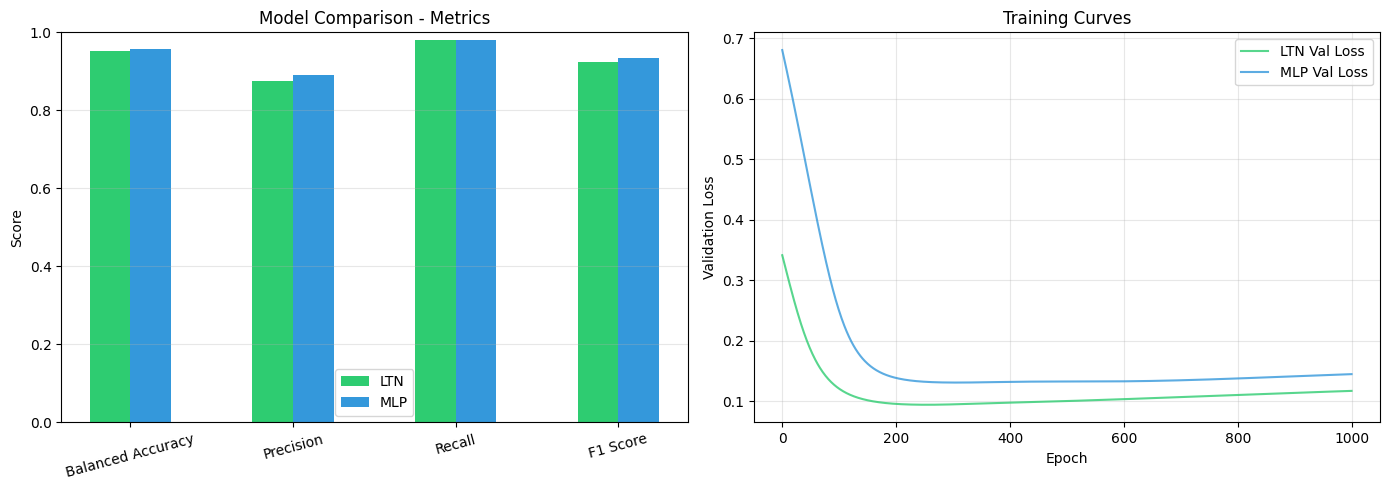

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Build comparison dataframe
comparison_data = []
for model_name, model_results in results.items():
    if 'metrics' in model_results:
        m = model_results['metrics']
        comparison_data.append({
            'Model': model_name.upper(),
            'Balanced Accuracy': m['balanced_accuracy'],
            'Precision': m['precision'],
            'Recall': m['recall'],
            'F1 Score': m['f1']
        })

if comparison_data:
    df = pd.DataFrame(comparison_data)
    print("\n" + "=" * 60)
    print("MODEL COMPARISON")
    print("=" * 60)
    print(df.to_string(index=False))
    print("=" * 60)
    
    # Bar chart comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Metrics comparison
    metrics_to_plot = ['Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    x = np.arange(len(metrics_to_plot))
    width = 0.25
    
    colors = {'LTN': '#2ecc71', 'MLP': '#3498db', 'RULES_ONLY': '#e74c3c'}
    
    for i, row in df.iterrows():
        model = row['Model']
        values = [row[m] for m in metrics_to_plot]
        offset = (i - len(df)/2 + 0.5) * width
        axes[0].bar(x + offset, values, width, label=model, color=colors.get(model, '#95a5a6'))
    
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Comparison - Metrics')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_to_plot, rotation=15)
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Training curves (LTN vs MLP)
    if 'ltn' in results and 'history' in results['ltn']:
        axes[1].plot(results['ltn']['history']['val_losses'], label='LTN Val Loss', color='#2ecc71', alpha=0.8)
    if 'mlp' in results and 'history' in results['mlp']:
        axes[1].plot(results['mlp']['history']['val_losses'], label='MLP Val Loss', color='#3498db', alpha=0.8)
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Training Curves')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No models to compare")

## Save Results

In [13]:
# Save comparison results to JSON
output_results = {
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
    'config': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'seed': RANDOM_SEED
    },
    'models': {}
}

for model_name, model_results in results.items():
    output_results['models'][model_name] = {
        'metrics': {k: v for k, v in model_results.get('metrics', {}).items() if k != 'predictions'},
        'best_epoch': model_results.get('history', {}).get('best_epoch'),
        'training_time': model_results.get('history', {}).get('training_time')
    }

results_path = os.path.join(OUTPUT_DIR, "notebook_comparison_results.json")
with open(results_path, 'w') as f:
    json.dump(output_results, f, indent=2)

print(f"Results saved to {results_path}")
print("\nSaved models:")
print(f"  - LTN: {LTN_MODEL_PATH}")
print(f"  - MLP: {MLP_MODEL_PATH}")
print("\nYou can now use these models in the Streamlit app!")

Results saved to /app/output/notebook_comparison_results.json

Saved models:
  - LTN: /app/output/ltn.h5
  - MLP: /app/output/mlp.h5

You can now use these models in the Streamlit app!
